### Data Processing Update

The data processing stage for LLMDet reproduction has been completed.

#### Completed Work

- Prepared and organized the required dataset structure under `huggingface/`, `grounding_data/`, and `LLMDet/`
- Verified the existence of all required training and validation annotation files
- Checked annotation-image consistency for the main training datasets
- Confirmed that the correct local V3Det annotation file is  
  `grounding_data/v3det/annotations/v3det_available.jsonl`
- Cleaned the training annotations for COCO, Flickr30k, and GQA
- Re-checked the cleaned annotations and confirmed that all final training annotation files pass the missing/malformed field check
- Verified that `instances_val2017.json` for COCO validation also passes the annotation check
- Confirmed that the shared project directory contains all required files, image folders, pretrained resources, and config files

#### Current Status

The final local/shared data version has been cleaned, validated, and aligned with the training config.  
The dataset is now ready for downstream model-side use.

#### Dataset Directory Structure

```text
dataset/
├── huggingface/
│   ├── bert-base-uncased/
│   ├── siglip-so400m-patch14-384/
│   ├── my_llava-onevision-qwen2-0.5b-ov-2/
│   └── mm_grounding_dino/
│       ├── grounding_dino_swin-t_pretrain_obj365_goldg_grit9m_v3det_20231204_095047-b448804b.pth
│       ├── grounding_dino_swin-b_pretrain_obj365_goldg_v3de-f83eef00.pth
│       └── grounding_dino_swin-l_pretrain_obj365_goldg-34dcdc53.pth
│
├── grounding_data/
│   ├── coco/
│   │   ├── annotations/
│   │   │   ├── instances_train2017_vg_merged6.cleaned.jsonl
│   │   │   ├── instances_val2017.json
│   │   │   ├── lvis_v1_minival_inserted_image_name.json
│   │   │   └── lvis_od_val.json
│   │   ├── train2017/
│   │   └── val2017/
│   │
│   ├── flickr30k_entities/
│   │   ├── flickr_train_vg7.cleaned.jsonl
│   │   └── flickr30k_images/
│   │
│   ├── gqa/
│   │   ├── gqa_train_vg7.cleaned.jsonl
│   │   └── images/
│   │
│   ├── llava_cap/
│   │   ├── LLaVA-ReCap-558K_tag_box_vg7.jsonl
│   │   └── images/
│   │
│   └── v3det/
│       ├── annotations/
│       │   └── v3det_available.jsonl
│       └── images/
│
└── LLMDet/
    └── configs/
        └── grounding_dino_swin_t.py
```

#### Dataset Preparation Summary

| Dataset | Images | Final Annotation | Status | Notes |
|---------|-------:|------------------|--------|-------|
| COCO train | 118287 | `instances_train2017_vg_merged6.cleaned.jsonl` | PASS | Final cleaned version used |
| COCO val | 5000 | `instances_val2017.json` | PASS | Validation split ready |
| Flickr30k | 31783 | `flickr_train_vg7.cleaned.jsonl` | PASS | Final cleaned version used |
| GQA | 148854 | `gqa_train_vg7.cleaned.jsonl` | PASS | Final cleaned version used |
| LLaVA-ReCap | 558128 | `LLaVA-ReCap-558K_tag_box_vg7.jsonl` | PASS | Original annotation retained |
| V3Det | 165465 | `v3det_available.jsonl` | PASS | Final local annotation used |

##### Image Directories

- COCO train: `grounding_data/coco/train2017`
- COCO val: `grounding_data/coco/val2017`
- Flickr30k: `grounding_data/flickr30k_entities/flickr30k_images`
- GQA: `grounding_data/gqa/images`
- LLaVA-ReCap: `grounding_data/llava_cap/images`
- V3Det: `grounding_data/v3det/images`

##### Additional Resources

- `huggingface/bert-base-uncased`
- `huggingface/siglip-so400m-patch14-384`
- `huggingface/my_llava-onevision-qwen2-0.5b-ov-2`
- `huggingface/mm_grounding_dino/grounding_dino_swin-t_pretrain_obj365_goldg_grit9m_v3det_20231204_095047-b448804b.pth`
- `huggingface/mm_grounding_dino/grounding_dino_swin-b_pretrain_obj365_goldg_v3de-f83eef00.pth`
- `huggingface/mm_grounding_dino/grounding_dino_swin-l_pretrain_obj365_goldg-34dcdc53.pth`

In [38]:
import json
import random
import zipfile
from io import BytesIO
from pathlib import Path
import tarfile

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# change root to your own address
root = Path("/Users/xyzeng/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/DSA5106 Group22")

dataset_name = "Flickr30k cleaned"
# Options:
# "COCO cleaned"
# "Flickr30k cleaned"
# "GQA cleaned"
# "LLaVA-ReCap"
# "V3Det available"

dataset_map = {
    "COCO cleaned": {
        "ann": root / "grounding_data/coco/annotations/instances_train2017_vg_merged6.cleaned.jsonl",
        "img_dir": root / "grounding_data/coco/train2017",
        "img_zip": root / "grounding_data/coco/train2017.zip",
        "zip_prefix": "",
    },
    "Flickr30k cleaned": {
        "ann": root / "grounding_data/flickr30k_entities/flickr_train_vg7.cleaned.jsonl",
        "img_dir": root / "grounding_data/flickr30k_entities/flickr30k_images",
        "img_zip": root / "grounding_data/flickr30k_entities/flickr30k_images.zip",
        "zip_prefix": "",
    },
    "GQA cleaned": {
        "ann": root / "grounding_data/gqa/gqa_train_vg7.cleaned.jsonl",
        "img_dir": root / "grounding_data/gqa/images",
        "img_zip": root / "grounding_data/gqa/images.zip",
        "zip_prefix": "",
    },
    "LLaVA-ReCap": {
        "ann": root / "grounding_data/llava_cap/LLaVA-ReCap-558K_tag_box_vg7.jsonl",
        "img_dir": root / "grounding_data/llava_cap/images",
        "img_zip": root / "grounding_data/llava_cap/images.zip",
        "zip_prefix": "",
    },
    "V3Det available": {
        "ann": root / "grounding_data/v3det/annotations/v3det_available.jsonl",
        "img_dir": root / "grounding_data/v3det/images",
        "img_zip": root / "grounding_data/v3det/images.zip",
        "zip_prefix": "images/",
    },
}

cfg = dataset_map[dataset_name]
ann_path = cfg["ann"]
img_dir = cfg["img_dir"]
img_zip = cfg["img_zip"]
zip_prefix = cfg["zip_prefix"]

In [ ]:
IMG_SUFFIXES = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def is_real_image_file(name: str) -> bool:
    base = Path(name).name
    lower = base.lower()
    return (
        lower.endswith((".jpg", ".jpeg", ".png"))
        and not base.startswith("._")
    )

def count_images_in_zip(zip_path):
    if not zip_path.exists():
        return 0

    if zip_path.suffix.lower() == ".zip":
        with zipfile.ZipFile(zip_path, "r") as zf:
            names = zf.namelist()
        return sum(1 for n in names if is_real_image_file(n))

    if zip_path.name.lower().endswith(".tar.gz") or zip_path.suffix.lower() == ".tgz":
        with tarfile.open(zip_path, "r:gz") as tf:
            names = tf.getnames()
        return sum(1 for n in names if is_real_image_file(n))

    return 0

def find_member_in_zip(zf, filename, zip_prefix=""):
    candidates = []
    filename = str(filename).replace("\\", "/")

    candidates.append(filename)
    candidates.append(Path(filename).name)

    if zip_prefix:
        prefix = zip_prefix.rstrip("/") + "/"
        candidates.append(prefix + filename)
        candidates.append(prefix + Path(filename).name)

    seen = set()
    candidates = [x for x in candidates if not (x in seen or seen.add(x))]

    names = set(zf.namelist())
    for c in candidates:
        if c in names:
            return c

    basename = Path(filename).name
    matches = [n for n in names if Path(n).name == basename and not n.endswith("/")]
    if len(matches) == 1:
        return matches[0]

    return None

def load_image(sample_filename, img_dir, img_zip, zip_prefix=""):
    p = img_dir / sample_filename
    if p.exists():
        return Image.open(p), str(p), True

    if img_zip.exists():
        with zipfile.ZipFile(img_zip, "r") as zf:
            member = find_member_in_zip(zf, sample_filename, zip_prefix=zip_prefix)
            if member is not None:
                data = zf.read(member)
                img = Image.open(BytesIO(data))
                return img, f"{img_zip}::{member}", True

    return None, str(p), False

In [40]:
print("=" * 100)
print("Dataset:", dataset_name)
print("Annotation file:", ann_path)
print("Image directory exists:", img_dir.exists(), "|", img_dir)
print("Image zip exists:", img_zip.exists(), "|", img_zip)

zip_img_count = count_images_in_zip(img_zip)
print("Image count in zip:", zip_img_count)
print("=" * 100)

n = 5

with open(ann_path, "r", encoding="utf-8") as f:
    lines = [line for line in f if line.strip()]

sample_lines = random.sample(lines, min(n, len(lines)))
samples = [json.loads(line) for line in sample_lines]

rows = []
for i, obj in enumerate(samples):
    rows.append({
        "idx": i,
        "filename": obj.get("filename"),
        "height": obj.get("height"),
        "width": obj.get("width"),
        "caption": obj.get("grounding", {}).get("caption", "")[:120],
        "num_regions": len(obj.get("grounding", {}).get("regions", [])),
        "num_conversations": len(obj.get("conversations", [])),
        "num_tags": len(obj.get("tags", [])),
    })

df = pd.DataFrame(rows)
display(df)

Dataset: Flickr30k cleaned
Annotation file: /Users/xyzeng/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/DSA5106 Group22/grounding_data/flickr30k_entities/flickr_train_vg7.cleaned.jsonl
Image directory exists: False | /Users/xyzeng/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/DSA5106 Group22/grounding_data/flickr30k_entities/flickr30k_images
Image zip exists: True | /Users/xyzeng/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/DSA5106 Group22/grounding_data/flickr30k_entities/flickr30k_images.zip
Image count in zip: 31783


,idx,filename,height,width,caption,num_regions,num_conversations,num_tags
0,0,141734985.jpg,375,500,Two kids with helmets on sitting outside while...,7,2,10
1,1,4095229112.jpg,332,500,Two men wearing hats stand behind a table with...,15,2,22
2,2,4733490834.jpg,333,500,A teenage blond girl talks on her cellphone as...,7,2,9
3,3,3461110860.jpg,333,500,Man wearing pass on a lanyard and standing in ...,5,2,14
4,4,2389238787.jpg,375,500,An older man with a blue coat and black hat is...,6,2,8


Dataset: Flickr30k cleaned
Sample index in sampled set: 0
Filename: 141734985.jpg
Height: 375 Width: 500
Caption: Two kids with helmets on sitting outside while one looks down and the other straight ahead . Two little boys in bike helmets hanging out . Two young males wear silver helmets .space. piece. sport. sort. machinery. print. silver color. metal structures. head protection. 
Number of regions: 7
Number of conversations: 2
Number of tags: 10

First region:
{'bbox': [79.0, 89.0, 449.0, 374.0], 'phrase': 'Two kids', 'tokens_positive': [[0, 8]]}

Resolved image source: /Users/xyzeng/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/DSA5106 Group22/grounding_data/flickr30k_entities/flickr30k_images.zip::flickr30k_images/141734985.jpg
Image exists: True


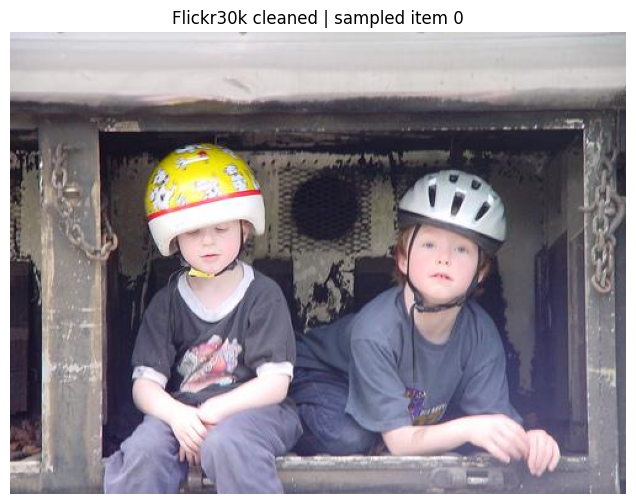

In [41]:
sample_idx = 0
sample = samples[sample_idx]

print("=" * 100)
print("Dataset:", dataset_name)
print("Sample index in sampled set:", sample_idx)
print("Filename:", sample.get("filename"))
print("Height:", sample.get("height"), "Width:", sample.get("width"))
print("Caption:", sample.get("grounding", {}).get("caption", ""))
print("Number of regions:", len(sample.get("grounding", {}).get("regions", [])))
print("Number of conversations:", len(sample.get("conversations", [])))
print("Number of tags:", len(sample.get("tags", [])))

regions = sample.get("grounding", {}).get("regions", [])
if regions:
    print("\nFirst region:")
    print(regions[0])
else:
    print("\nNo regions found.")

img, img_source, exists = load_image(
    sample_filename=sample["filename"],
    img_dir=img_dir,
    img_zip=img_zip,
    zip_prefix=zip_prefix
)

print("\nResolved image source:", img_source)
print("Image exists:", exists)

if exists:
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{dataset_name} | sampled item {sample_idx}")
    plt.show()
else:
    print("Image file not found in either directory or zip.")

,idx,file_name,height,width,num_annotations,categories_preview
0,0,000000417876.jpg,375,500,6,"giraffe, giraffe, bird, bird, bird"
1,1,000000170191.jpg,531,640,3,"bed, person, suitcase"
2,2,000000067616.jpg,480,640,37,"car, car, fire hydrant, person, person"
3,3,000000402118.jpg,428,640,2,"person, snowboard"
4,4,000000338905.jpg,360,480,38,"bottle, motorcycle, motorcycle, bottle, chair"


Dataset: COCO val
Sample index: 0
Image path: /Users/xyzeng/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/DSA5106 Group22/grounding_data/coco/val2017/000000417876.jpg
Image exists: True
File name: 000000417876.jpg
Height: 375 Width: 500
Number of annotations: 6

First annotation:
{'segmentation': [[221.63, 299.16, 221.63, 247.75, 212.36, 195.51, 218.26, 164.33, 218.26, 127.25, 203.93, 109.55, 203.93, 101.12, 214.89, 96.91, 228.37, 110.39, 239.33, 163.48, 263.76, 199.72, 258.71, 260.39, 262.92, 302.53]], 'area': 6668.6732999999995, 'iscrowd': 0, 'image_id': 417876, 'bbox': [203.93, 96.91, 59.83, 205.62], 'category_id': 25, 'id': 595498}
Category name: giraffe


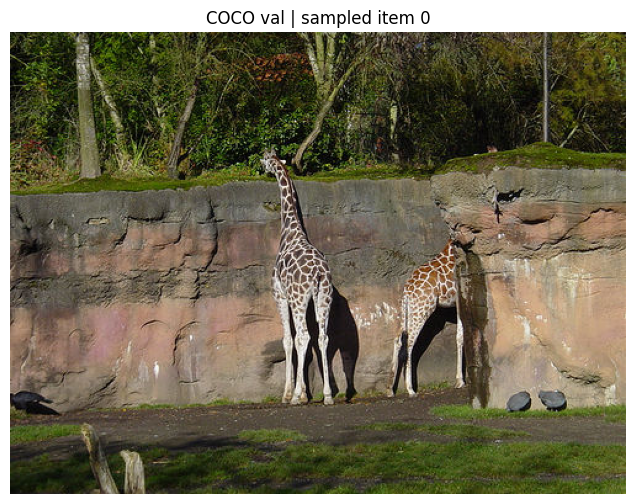

In [42]:
## COCO val
ann_path = root / "grounding_data/coco/annotations/instances_val2017.json"
img_dir = root / "grounding_data/coco/val2017"

with open(ann_path, "r", encoding="utf-8") as f:
    coco = json.load(f)

images = coco["images"]
annotations = coco["annotations"]
categories = coco["categories"]

cat_id_to_name = {c["id"]: c["name"] for c in categories}

# group annotations by image_id
ann_by_image = {}
for ann in annotations:
    ann_by_image.setdefault(ann["image_id"], []).append(ann)

# random sample images
n = 5
sample_images = random.sample(images, min(n, len(images)))

rows = []
for i, img in enumerate(sample_images):
    anns = ann_by_image.get(img["id"], [])
    cat_names = [cat_id_to_name.get(a["category_id"], "unknown") for a in anns]
    rows.append({
        "idx": i,
        "file_name": img["file_name"],
        "height": img["height"],
        "width": img["width"],
        "num_annotations": len(anns),
        "categories_preview": ", ".join(cat_names[:5]),
    })

df = pd.DataFrame(rows)
display(df)

sample_idx = 0
sample = sample_images[sample_idx]
anns = ann_by_image.get(sample["id"], [])

img_path = img_dir / sample["file_name"]

print("=" * 100)
print("Dataset: COCO val")
print("Sample index:", sample_idx)
print("Image path:", img_path)
print("Image exists:", img_path.exists())
print("File name:", sample["file_name"])
print("Height:", sample["height"], "Width:", sample["width"])
print("Number of annotations:", len(anns))

if anns:
    print("\nFirst annotation:")
    print(anns[0])
    print("Category name:", cat_id_to_name.get(anns[0]["category_id"], "unknown"))
else:
    print("\nNo annotations found.")

if img_path.exists():
    img = Image.open(img_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"COCO val | sampled item {sample_idx}")
    plt.show()
else:
    print("Image file not found.")

If you unzipped the file you can use the following code.

,idx,filename,height,width,caption,num_regions,num_conversations,num_tags
0,0,000000298747.jpg,395,640,handbag. person. cake. tie. train. cow. potted...,6,2,17
1,1,000000537170.jpg,495,640,boat. toothbrush. horse. remote. kite. giraffe...,2,2,11
2,2,000000238105.jpg,333,500,bed. fork. broccoli. car. person. laptop. benc...,6,2,17
3,3,000000272846.jpg,309,640,bear. couch. spoon. scissors. cat. boat. truck...,6,2,21
4,4,000000315728.jpg,480,640,hot dog. oven. fork. microwave. sandwich. cow....,8,2,24


Dataset: COCO cleaned
Sample index in sampled set: 0
Image path: /Users/xyzeng/Desktop/yr5 term2/DSA5106/project/dataset/grounding_data/coco/train2017/000000298747.jpg
Image exists: True
Filename: 000000298747.jpg
Height: 395 Width: 640
Caption: handbag. person. cake. tie. train. cow. potted plant. fork. motorcycle. tv. pizza. apple. mouse. backpack. toaster. scissors. tennis racket. clock. sink. sports ball. bus. giraffe. oven. cat. bicycle. truck. dining table. wine glass. banana. frisbee. donut. keyboard. zebra. dog. skis. book. bear. cell phone. hair drier. snowboard. stop sign. kite. toothbrush. suitcase. parking meter. teddy bear. airplane. spoon. knife. boat. broccoli. horse. surfboard. fire hydrant. refrigerator. sheep. hot dog. toilet. elephant. baseball bat. remote. chair. umbrella. carrot. cup. skateboard. vase. orange. microwave. traffic light. baseball glove. bottle. couch. bench. car. bird. sandwich. laptop. bed. bowl. flag. pier. smoke. water. mast. text. backdrop. body.

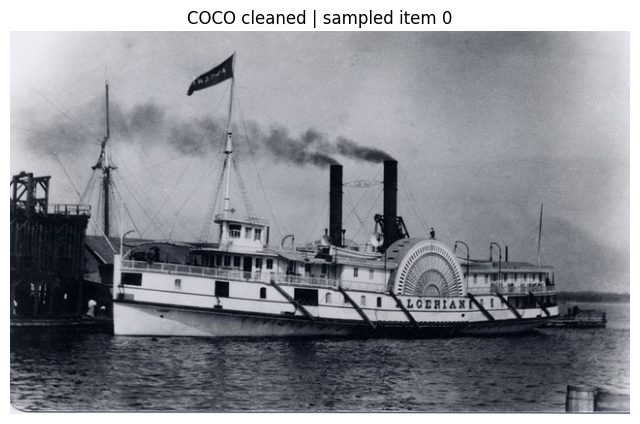

In [43]:
import json
import random
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# change root to your own address
root = Path("/Users/xyzeng/Desktop/yr5 term2/DSA5106/project/dataset")

dataset_name = "COCO cleaned"
# Options:
# "COCO cleaned"
# "Flickr30k cleaned"
# "GQA cleaned"
# "LLaVA-ReCap"
# "V3Det available"

dataset_map = {
    "COCO cleaned": {
        "ann": root / "grounding_data/coco/annotations/instances_train2017_vg_merged6.cleaned.jsonl",
        "img_dir": root / "grounding_data/coco/train2017",
    },
    "Flickr30k cleaned": {
        "ann": root / "grounding_data/flickr30k_entities/flickr_train_vg7.cleaned.jsonl",
        "img_dir": root / "grounding_data/flickr30k_entities/flickr30k_images",
    },
    "GQA cleaned": {
        "ann": root / "grounding_data/gqa/gqa_train_vg7.cleaned.jsonl",
        "img_dir": root / "grounding_data/gqa/images",
    },
    "LLaVA-ReCap": {
        "ann": root / "grounding_data/llava_cap/LLaVA-ReCap-558K_tag_box_vg7.jsonl",
        "img_dir": root / "grounding_data/llava_cap/images",
    },
    "V3Det available": {
        "ann": root / "grounding_data/v3det/annotations/v3det_available.jsonl",
        "img_dir": root / "grounding_data/v3det",
    },
}

ann_path = dataset_map[dataset_name]["ann"]
img_dir = dataset_map[dataset_name]["img_dir"]

n = 5

with open(ann_path, "r", encoding="utf-8") as f:
    lines = [line for line in f if line.strip()]

sample_lines = random.sample(lines, min(n, len(lines)))
samples = [json.loads(line) for line in sample_lines]

rows = []
for i, obj in enumerate(samples):
    rows.append({
        "idx": i,
        "filename": obj.get("filename"),
        "height": obj.get("height"),
        "width": obj.get("width"),
        "caption": obj.get("grounding", {}).get("caption", "")[:120],
        "num_regions": len(obj.get("grounding", {}).get("regions", [])),
        "num_conversations": len(obj.get("conversations", [])),
        "num_tags": len(obj.get("tags", [])),
    })

df = pd.DataFrame(rows)
display(df)

sample_idx = 0
sample = samples[sample_idx]

img_path = img_dir / sample["filename"]

print("=" * 100)
print("Dataset:", dataset_name)
print("Sample index in sampled set:", sample_idx)
print("Image path:", img_path)
print("Image exists:", img_path.exists())
print("Filename:", sample.get("filename"))
print("Height:", sample.get("height"), "Width:", sample.get("width"))
print("Caption:", sample.get("grounding", {}).get("caption", ""))
print("Number of regions:", len(sample.get("grounding", {}).get("regions", [])))
print("Number of conversations:", len(sample.get("conversations", [])))
print("Number of tags:", len(sample.get("tags", [])))

regions = sample.get("grounding", {}).get("regions", [])
if regions:
    print("\nFirst region:")
    print(regions[0])
else:
    print("\nNo regions found.")

if img_path.exists():
    img = Image.open(img_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{dataset_name} | sampled item {sample_idx}")
    plt.show()
else:
    print("Image file not found.")